# EDA and Preprocessing

## EDA

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

from funcs import *
import warnings

set_env()
warnings.filterwarnings('ignore')

Dataset

>@inproceedings{Pogorelov:2017:KMI:3083187.3083212,
  title = {KVASIR: A Multi-Class Image Dataset for Computer Aided Gastrointestinal Disease Detection},
  author = {
     Pogorelov, Konstantin and Randel, Kristin Ranheim and Griwodz, Carsten and
     Eskeland, Sigrun Losada and de Lange, Thomas and Johansen, Dag and
     Spampinato, Concetto and Dang-Nguyen, Duc-Tien and Lux, Mathias and
     Schmidt, Peter Thelin and Riegler, Michael and Halvorsen, P{\aa}l
  },
  booktitle = {Proceedings of the 8th ACM on Multimedia Systems Conference},
  series = {MMSys'17},
  year = {2017},
  isbn = {978-1-4503-5002-0},
  location = {Taipei, Taiwan},
  pages = {164--169},
  numpages = {6},
  doi = {10.1145/3083187.3083212},
  acmid = {3083212},
  publisher = {ACM},
  address = {New York, NY, USA},
}

In [23]:
# Show an image - example

sample_img = Image.open(r"samples\0a42cb65-e906-46b3-936a-f5f1dc71f108.jpg"); # Sample image
# img.show()

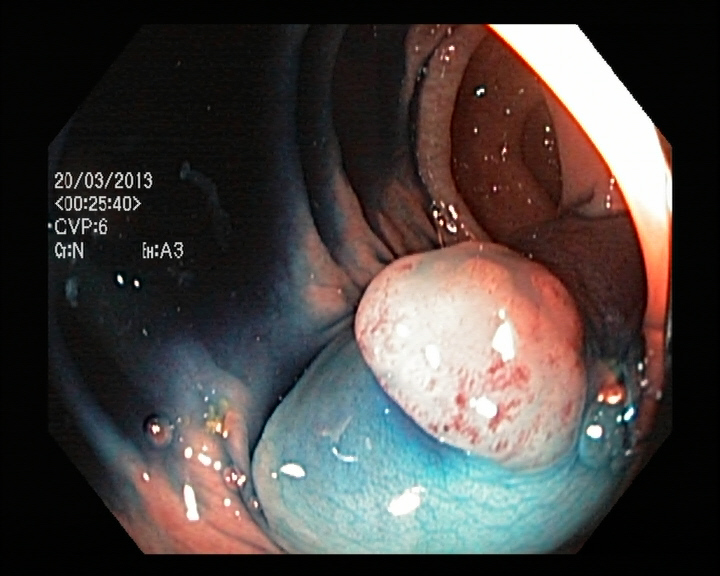

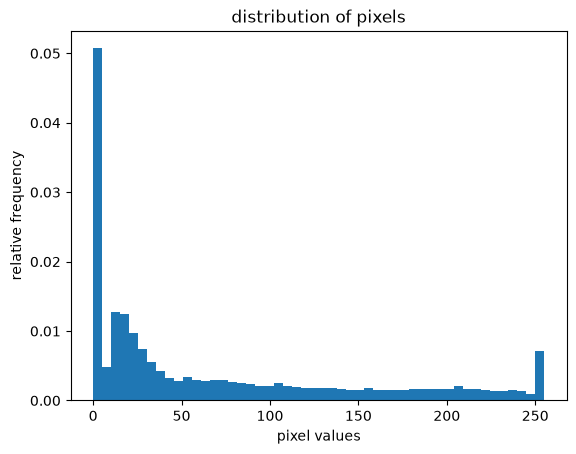

In [24]:
img_np = np.array(sample_img)

# plot the pixel values
plt.hist(img_np.ravel(), bins=50, density=True)
plt.xlabel("pixel values")
plt.ylabel("relative frequency")
plt.title("distribution of pixels")
plt.show()

From the dataset's page "...*the dataset consist of the images with different resolution from 720x576 up to 1920x1072 pixels and organized in a way where they are sorted in separate folders named accordingly to the content*". So we want, firstly to resize to a managble size (to the smalles image, I will scale up if the model requires)

In [25]:
sample_img.size

(720, 576)

In [26]:
sample_img = sample_img.resize((256,256))
sample_img = sample_img

### Labels

In [27]:
for subdir, dirs, files in os.walk(DATA_DIR):
    print(dirs)
    print(len(files))

['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
0
[]
1000
[]
1000
[]
1000
[]
1000
[]
1000
[]
1000
[]
1000
[]
1000


## Preprocessing

In [ ]:
# Look for bad files

base_dataset = ImageFolder(root=DATA_DIR)

records = []
bad_files = []

for path, label in base_dataset.samples:
    try:
        with Image.open(path) as img:
            img.verify()
        #p = str(path).split('\\')[-2]+"\\"+os.path.basename(path)
        p = path
        records.append({"path": p, "label": label, "class_name": base_dataset.classes[label]})
    except (OSError, ValueError, UnidentifiedImageError) as exc:
        bad_files.append((path, str(exc)))

df = pd.DataFrame(records)

print(f"Valid images: {len(df)}")
print(f"Classes ({len(base_dataset.classes)}): {base_dataset.classes}")
print("\nClass counts:")
print(df["class_name"].value_counts().sort_index())

if bad_files:
    print(f"\nUnreadable images: {len(bad_files)}")
    for path, error in bad_files[:10]:
        print(path, error)

Valid images: 8000
Classes (8): ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']

Class counts:
class_name
dyed-lifted-polyps        1000
dyed-resection-margins    1000
esophagitis               1000
normal-cecum              1000
normal-pylorus            1000
normal-z-line             1000
polyps                    1000
ulcerative-colitis        1000
Name: count, dtype: int64


[dyed-lifted-polyps, dyed-resection-margins, esophagitis, normal-cecum, normal-pylorus, normal-z-line, polyps,ulcerative-colitis]

In [ ]:
# Train-test-val split (strtified to keep classes balanced 1/8)
train_df, temp_df = train_test_split(df, train_size=0.7,  random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, train_size=0.5, random_state=SEED, stratify=temp_df["label"])


# Saving the datasets
for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split.to_csv(OUTPUT_DIR + f"{name}.csv", index=False)
    print(f"\n{name}: {len(split)} images")


train: 5600 images

val: 1200 images

test: 1200 images


In [11]:
train_df.sample(5)

,path,label,class_name
1521,D:\Documentos\Fotos\data\dyed-resection-margin...,1,dyed-resection-margins
1401,D:\Documentos\Fotos\data\dyed-resection-margin...,1,dyed-resection-margins
2690,D:\Documentos\Fotos\data\esophagitis\b02cb6dd-...,2,esophagitis
2070,D:\Documentos\Fotos\data\esophagitis\12fbe984-...,2,esophagitis
715,D:\Documentos\Fotos\data\dyed-lifted-polyps\b1...,0,dyed-lifted-polyps


### Normalize

In [12]:
# ImageNet statistics, consistent with pretrained torchvision weights.
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.10, contrast=0.10, saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Transform to use in test and eval so there is no noise introduced
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

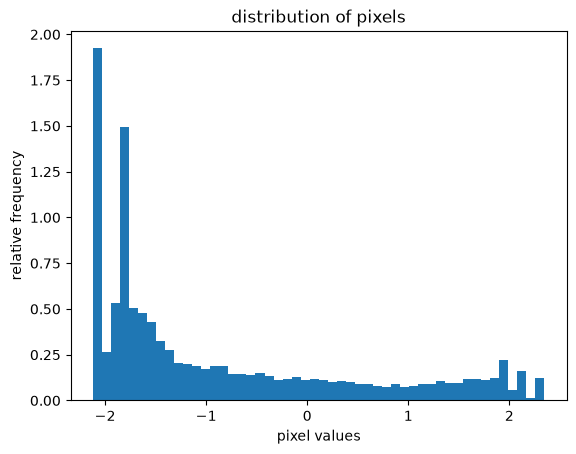

In [13]:
# Test on original image

transformed_img = train_transform(sample_img)
img_np = np.array(transformed_img)

# plot the pixel values
plt.hist(img_np.ravel(), bins=50, density=True)
plt.xlabel("pixel values")
plt.ylabel("relative frequency")
plt.title("distribution of pixels")
plt.show()

### Datasets

In [14]:
class KvasirDataset(Dataset): # Inherits from torch Datasets
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["path"]) as image:
            image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, int(row["label"])


train_dataset = KvasirDataset(train_df, train_transform)
val_dataset = KvasirDataset(val_df, eval_transform)
test_dataset = KvasirDataset(test_df, eval_transform)

### Data Loaders

In [15]:
cuda = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=cuda)
val_loader = DataLoader(val_dataset, shuffle=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=cuda)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=cuda)

In [16]:
images, labels = next(iter(train_loader))

print("Batch validation:")
print("Image tensor:", images.shape)  # [Batch, 3 (channels), IMAGE_SIZE, IMAGE_SIZE]
print("Labels:", labels.shape)        # [Batch]
print("Label range:", labels.min().item(), labels.max().item())
print("Device available:", DEVICE)
print("Class-to-index mapping:", base_dataset.class_to_idx)

Batch validation:
Image tensor: torch.Size([32, 3, 256, 256])
Labels: torch.Size([32])
Label range: 0 7
Device available: cpu
Class-to-index mapping: {'dyed-lifted-polyps': 0, 'dyed-resection-margins': 1, 'esophagitis': 2, 'normal-cecum': 3, 'normal-pylorus': 4, 'normal-z-line': 5, 'polyps': 6, 'ulcerative-colitis': 7}


**Everything looks good**, it can be scripted in `preprocessing.py`